# Matplotlib Visualization Using Gradio

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
import pandas as pd
# Sample data
data={
    "Month":["Jan","Feb","Mar","Apr","May","Jun"],
    "Sales":[10000,12000,15000,13000,17000,16000],
    "Profit":[2000,3000,4000,2500,3500,30000]
}
df=pd.DataFrame(data)

In [7]:
df=pd.DataFrame(data)

In [9]:
df

,Month,Sales,Profit
0,Jan,10000,2000
1,Feb,12000,3000
2,Mar,15000,4000
3,Apr,13000,2500
4,May,17000,3500
5,Jun,16000,30000


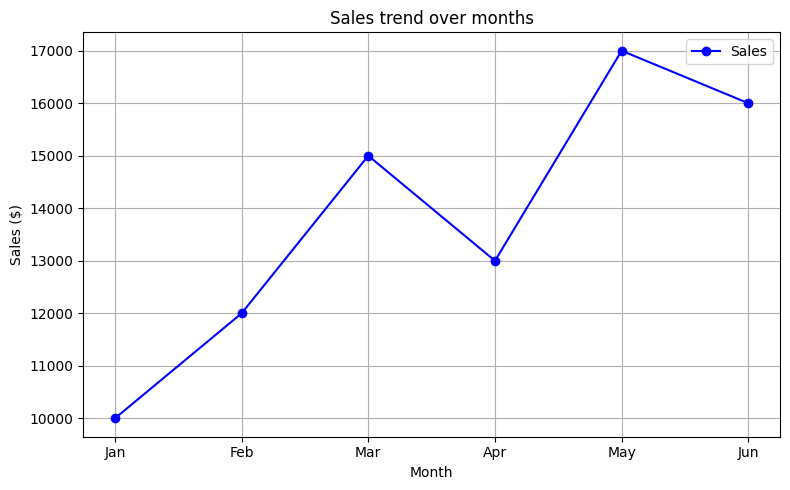

In [8]:
import matplotlib.pyplot as plt
#Line plot:Sales over time
plt.figure(figsize=(8,5))
plt.plot(df['Month'],df['Sales'],marker='o',color='b',label='Sales',linestyle='-')
plt.title('Sales trend over months')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

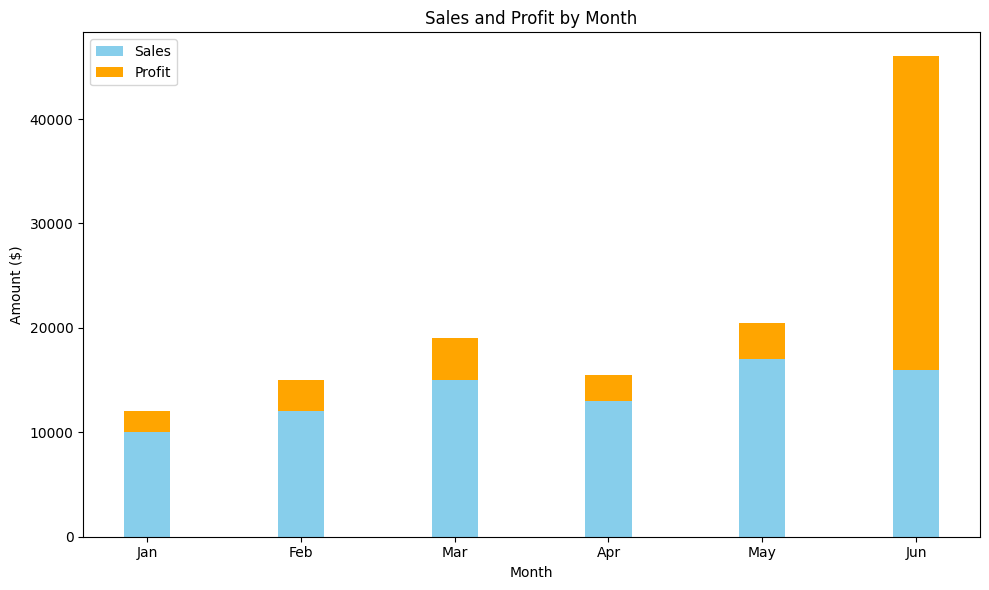

In [10]:
#Bar plot:Sales vs Profit by month
plt.figure(figsize=(10,6))
width=0.3
plt.bar(df['Month'],df['Sales'],width=width,label='Sales',color='skyblue')
plt.bar(df['Month'],df['Profit'],width=width,bottom=df['Sales'],label='Profit',color='orange')
plt.title('Sales and Profit by Month')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.legend()
plt.tight_layout()
plt.show()

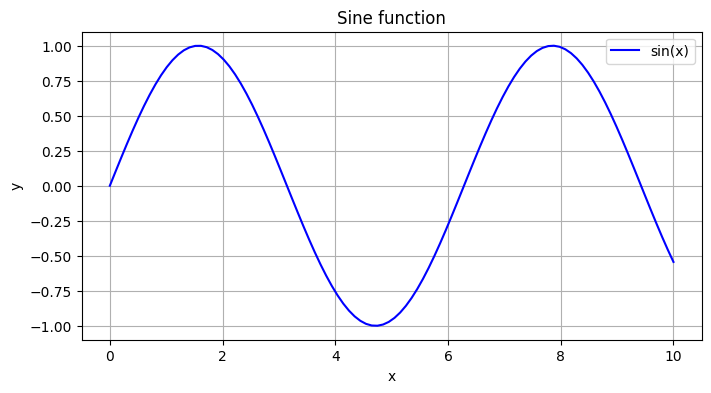

In [2]:
#line plot
x=np.linspace(0,10,100)
y=np.sin(x)

plt.figure(figsize=(8,4))
plt.plot(x,y,label="sin(x)",color='blue')
plt.title("Sine function")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

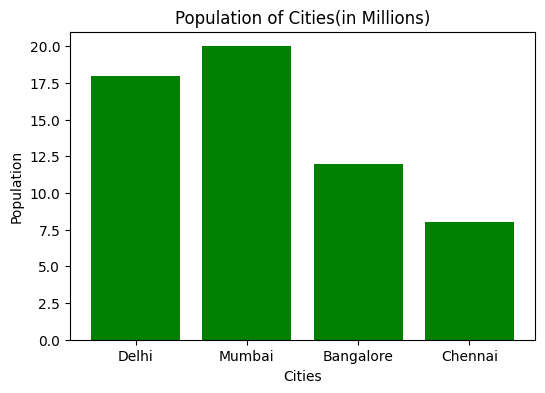

In [3]:
#Bar Chart
cities=['Delhi','Mumbai','Bangalore','Chennai']
population=[18,20,12,8]

plt.figure(figsize=(6,4))
plt.bar(cities,population,color='green')
plt.title("Population of Cities(in Millions)")
plt.xlabel("Cities")
plt.ylabel("Population")
plt.show()

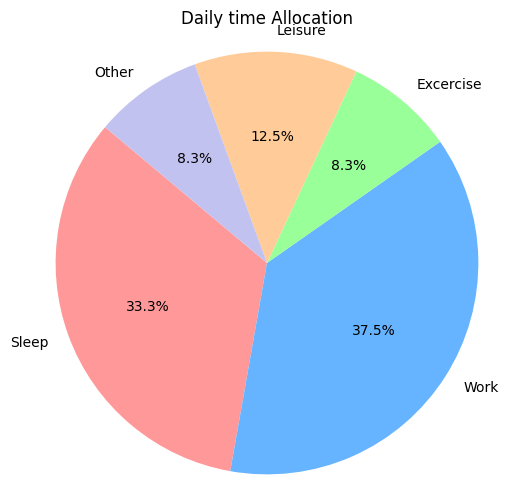

In [4]:
# Pie Chart
labels=['Sleep','Work','Excercise','Leisure','Other']
sizes=[8,9,2,3,2]
colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']

plt.figure(figsize=(6,6))
plt.pie(sizes,labels=labels,colors=colors,autopct='%1.1f%%',startangle=140)
plt.title("Daily time Allocation")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

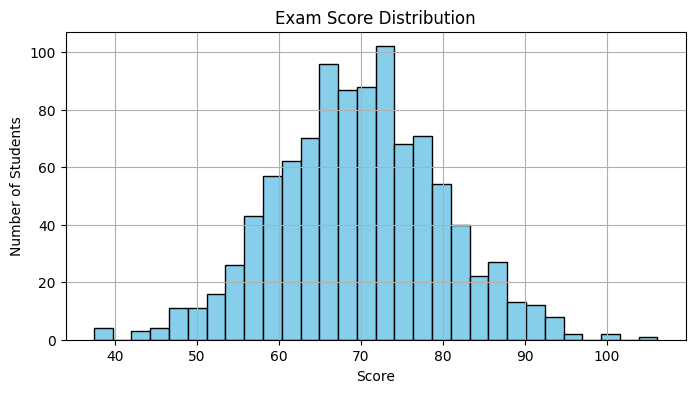

In [5]:
#Histogram
scores = np.random.normal(loc=70, scale=10, size=1000)
plt.figure(figsize=(8,4))
plt.hist(scores, bins=30, color='skyblue', edgecolor='black')
plt.title("Exam Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.grid(True)
plt.show()

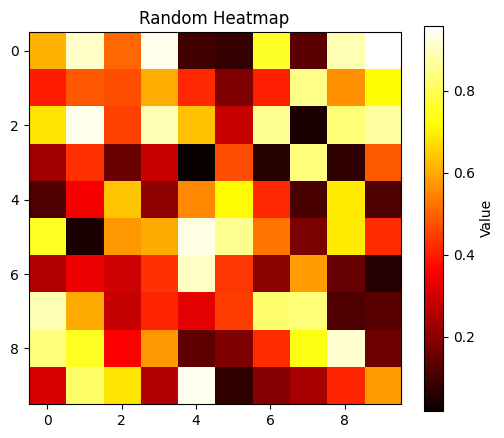

In [6]:
#heatmap
data = np.random.rand(10, 10)
plt.figure(figsize=(6, 5))
plt.imshow(data, cmap='hot', interpolation='nearest')
plt.colorbar(label='Value')
plt.title("Random Heatmap")
plt.show()

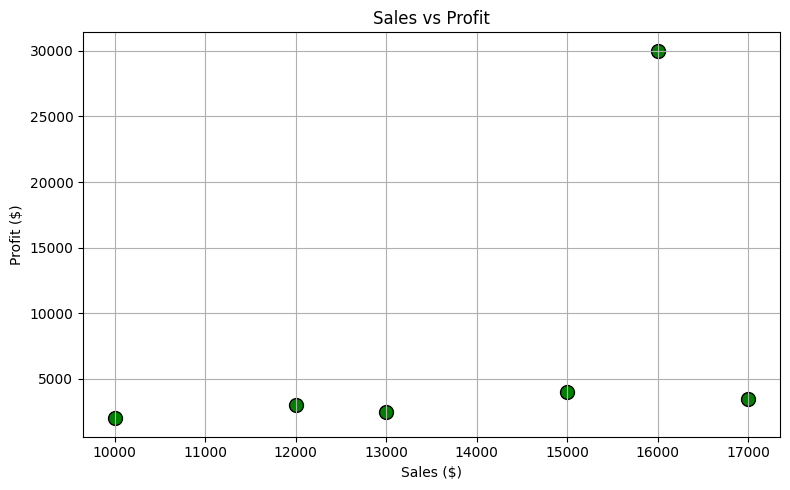

In [11]:
# Scatter Plot:Sales vs Profit(Correlation)
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'],df['Profit'],color='green',s=100,edgecolors='black')
plt.title('Sales vs Profit')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt

# Sample data
data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Sales": [10000, 12000, 15000, 13000, 17000, 16000],
    "Profit": [2000, 3000, 4000, 2500, 3500, 3000]
}
df = pd.DataFrame(data)

# Function to return selected plots
def generate_plots(plot_type):
    fig, ax = plt.subplots(figsize=(8,5))
    
    if plot_type == "Line Plot":
        ax.plot(df['Month'], df['Sales'], marker='o', color='b', label='Sales', linestyle='-')
        ax.set_title('Sales trend over months')
        ax.set_xlabel('Month')
        ax.set_ylabel('Sales ($)')
        ax.grid(True)
        ax.legend()
        
    elif plot_type == "Stacked Bar Plot":
        ax.bar(df['Month'], df['Sales'], label='Sales', color='skyblue')
        ax.bar(df['Month'], df['Profit'], bottom=df['Sales'], label='Profit', color='orange')
        ax.set_title('Sales and Profit by Month')
        ax.set_xlabel('Month')
        ax.set_ylabel('Amount ($)')
        ax.legend()
        
    elif plot_type == "Pie Chart":
        ax.pie(df['Sales'], labels=df['Month'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
        ax.set_title("Sales Distribution by Month")
        ax.axis('equal')  # Makes the pie circular
        
    elif plot_type == "Scatter Plot":
        ax.scatter(df['Sales'], df['Profit'], color='green', s=100, edgecolors='black')
        ax.set_title('Sales vs Profit')
        ax.set_xlabel('Sales ($)')
        ax.set_ylabel('Profit ($)')
        ax.grid(True)
        
    elif plot_type == "Histogram":
        ax.hist(df['Sales'], bins=5, color='skyblue', edgecolor='black')
        ax.set_title("Sales Distribution")
        ax.set_xlabel("Sales ($)")
        ax.set_ylabel("Frequency")
        ax.grid(True)
    
    elif plot_type == "Box Plot":
        ax.boxplot(df['Profit'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
        ax.set_title("Profit Distribution")
        ax.set_xlabel("Profit ($)")
        
    fig.tight_layout()
    return fig

# Gradio Interface
demo = gr.Interface(
    fn=generate_plots,
    inputs=gr.Radio(
        ["Line Plot", "Stacked Bar Plot", "Pie Chart", "Scatter Plot", "Histogram", "Box Plot"],
        label="Choose Plot Type"
    ),
    outputs=gr.Plot(label="Visualization"),
    title="Sales and Profit Visual Explorer",
    description="Choose a chart type to visualize the data."
)

demo.launch()


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
